<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
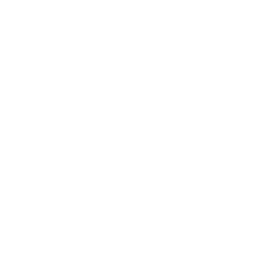
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Personeelsbenutting per Ziekenhuisafdeling — Horizontale Staafgrafiek</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Gezondheidszorg / Ziekenhuisbedrijfsvoering &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Dit voorbeeld gebruikt horizontale staafgrafieken (HBAR) van **PROC GCHART** om de personeelsuren te profileren over zes klinische afdelingen voor K1 2026. Een synthetisch personeelslogboek van **90 dienstrecords** (15 per afdeling) voedt drie weergaven: een gerangschikte staafgrafiek van totale uren, de gemiddelde dienstlengte per afdeling, en gegroepeerde HBAR's die elke afdeling opsplitsen naar personeelscategorie en naar dienst. `SUMVAR=` telt de werkelijke arbeidsuren op in plaats van records te tellen, `TYPE=SUM`/`TYPE=MEAN` schakelt tussen de responsstatistiek, `DESCENDING` rangschikt de afdelingen, en `GROUP=` tekent aangrenzende gegroepeerde staven voor een tweede dimensie.

De output ondersteunt de kwartaalbeoordeling van de operationele efficiëntie: het laat zien welke afdelingen de meeste arbeid verbruiken, welke de langste diensten draaien, en hoe het dag/avond/nacht-bezettingspatroon verschilt tussen afdelingen met continue zorgzwaarte en overwegend dagdienst-georiënteerde diensten.


## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Individuele dienstarbeidsrecords met gewerkte uren | 90 |
| WORK.DEPT_SUMMARY | Totalen en gemiddelde dienstlengte per afdeling | 6 |


---

In [1]:
/* --------------------------------------------------------
   Genereer een synthetisch ziekenhuis-personeelslogboek.
   K1 2026: 6 klinische afdelingen, 4 personeelscategorieën,
   3 diensten. Gedimensioneerd op 15 dienstrecords per afdeling
   (90 totaal) zodat het volledige afdelingsoverzicht zichtbaar blijft.
   -------------------------------------------------------- */
GEGEVENS work.staffing_log;
    CALL streaminit(20260601);
    LENGTE department $24 resource_type $16 shift $8;

    REEKS dept[6] $24 _temporary_
        ('Spoedeisende Hulp' 'Chirurgie' 'IC' 'Kindergeneeskunde'
         'Oncologie' 'Verloskunde');

    /* mix van personeelscategorieën (verpleegkundig-zwaar) */
    REEKS res[4]  $16 _temporary_
        ('Verpleging' 'Arts' 'Paramedisch' 'Ondersteuning');
    REEKS resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* basis dienstmix, verzwaard naar Nacht voor 24/7-afdelingen */
    REEKS shfw[3] _temporary_ (0.45 0.30 0.25);
    REEKS nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    DOE di = 1 TOT 6;
        department = dept[di];
        DOE rec = 1 TOT 15;

            /* personeelscategorie via gewogen trekking */
            u = rand('uniform'); cum = 0;
            DOE r = 1 TOT 4;
                cum + resw[r];
                ALS u <= cum DAN DOE;
                    resource_type = res[r];
                    VERLATEN;
                EINDE;
            EINDE;

            /* dienst via afdelingsspecifieke nachtverzwaring */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            ALS u <= w1 DAN shift = 'Dag';
            ANDERS ALS u <= w1 + w2 DAN shift = 'Avond';
            ANDERS shift = 'Nacht';

            /* uren: artsen en chirurgie draaien langere diensten */
            BASE = 8;
            ALS resource_type = 'Arts' DAN BASE = BASE + 1.5;
            ALS department = 'Chirurgie' DAN BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            ALS hours_worked < 4 DAN hours_worked = 4;

            UITVOER;
        EINDE;
    EINDE;
    BEWAREN department resource_type shift hours_worked;
    label department='Afdeling' resource_type='Personeelscategorie'
          shift='Dienst' hours_worked='Gewerkte Uren';
UITVOEREN;



NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Totalen en gemiddelde dienstlengte per afdeling,
   gerangschikt op totale arbeidsuren.
   -------------------------------------------------------- */
PROCEDURE SQL;
    CREATE TABLE work.dept_summary AS
    SELECTEREN department,
           sum(hours_worked)  AS total_hours   OPMAAK=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  OPMAAK=6.2
    FROM work.staffing_log
    GROUP VOLGENS department
    ORDER VOLGENS total_hours DESC;
QUIT;

PROCEDURE AFDRUKKEN GEGEVENS=work.dept_summary noobs label;
    label department     = 'Afdeling'
          total_hours   = 'Totaal Uren'
          shift_count   = 'Diensten'
          avg_shift_hrs = 'Gemiddelde Dienst (uur)';
    TITEL 'Overzicht Arbeidsuren per Afdeling - K1 2026';
UITVOEREN;
TITEL;


                                      Overzicht Arbeidsuren per Afdeling - K1 2026                                      

         Afdeling  Totaal Uren  Diensten  Gemiddelde Dienst (uur)
Chirurgie               136.25        15                     9.08
IC                      128.50        15                     8.57
Verloskunde             127.75        15                     8.52
Kindergeneeskunde       124.75        15                     8.32
Oncologie               123.75        15                     8.25
Spoedeisende Hulp       119.25        15                     7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                Arbeidsuren per Afdeling                                                

                                                  The MEANS Procedure

                                     Analysis Variable : hours_worked Gewerkte Uren

        Afdeling                     Sum           Mean          N Obs
        --------------------------------------------------------------
        Chirurgie                 136.25           9.08             15
        IC                        128.50           8.57             15
        Kindergeneeskunde         124.75           8.32             15
        Oncologie                 123.75           8.25             15
        Spoedeisende Hulp         119.25           7.95             15
        Verloskunde               127.75           8.52             15
        --------------------------------------------------------------

                                              Dienstverdeling per Afdeling        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


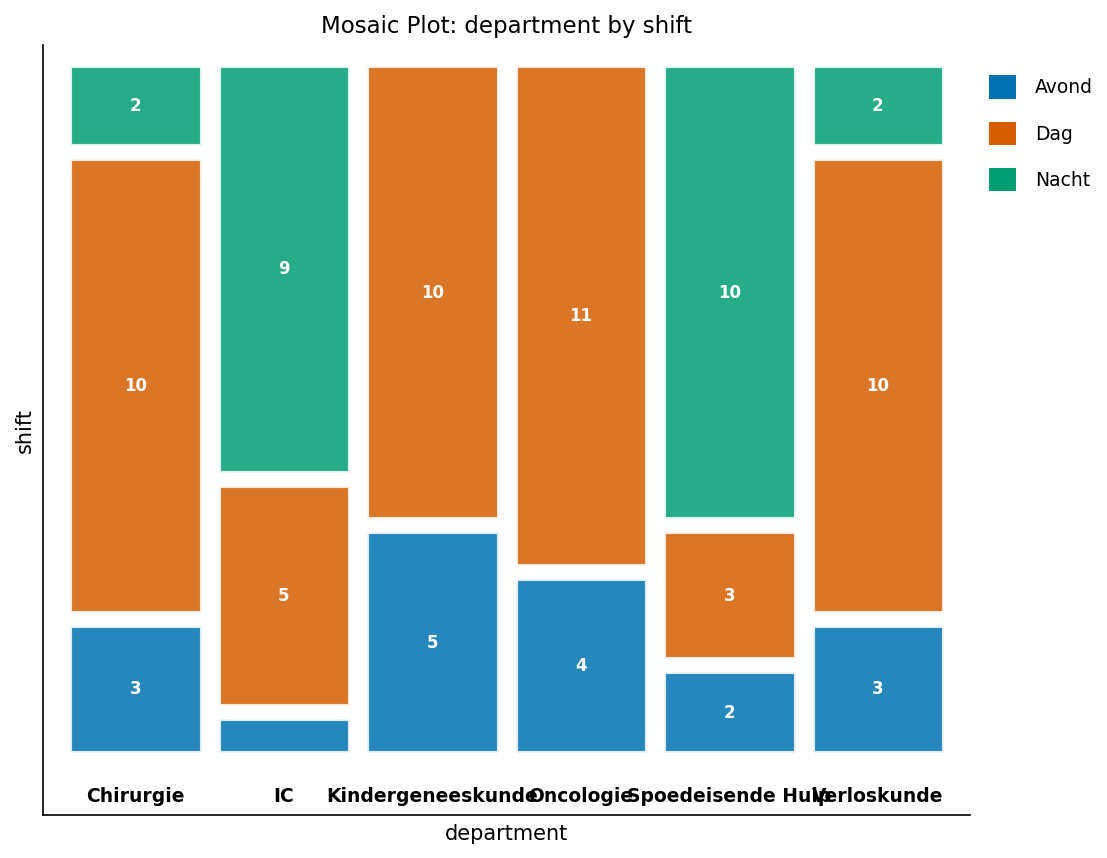

In [3]:
/* --------------------------------------------------------
   Basistabellen: arbeidsuren per afdeling, en de
   verdeling dag/avond/nacht per afdeling.
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.staffing_log sum mean n maxdec=2;
    KLASSE department;
    VARIABELE hours_worked;
    label department='Afdeling' hours_worked='Gewerkte Uren';
    TITEL 'Arbeidsuren per Afdeling';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    TITEL 'Dienstverdeling per Afdeling';
UITVOEREN;
TITEL;


---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


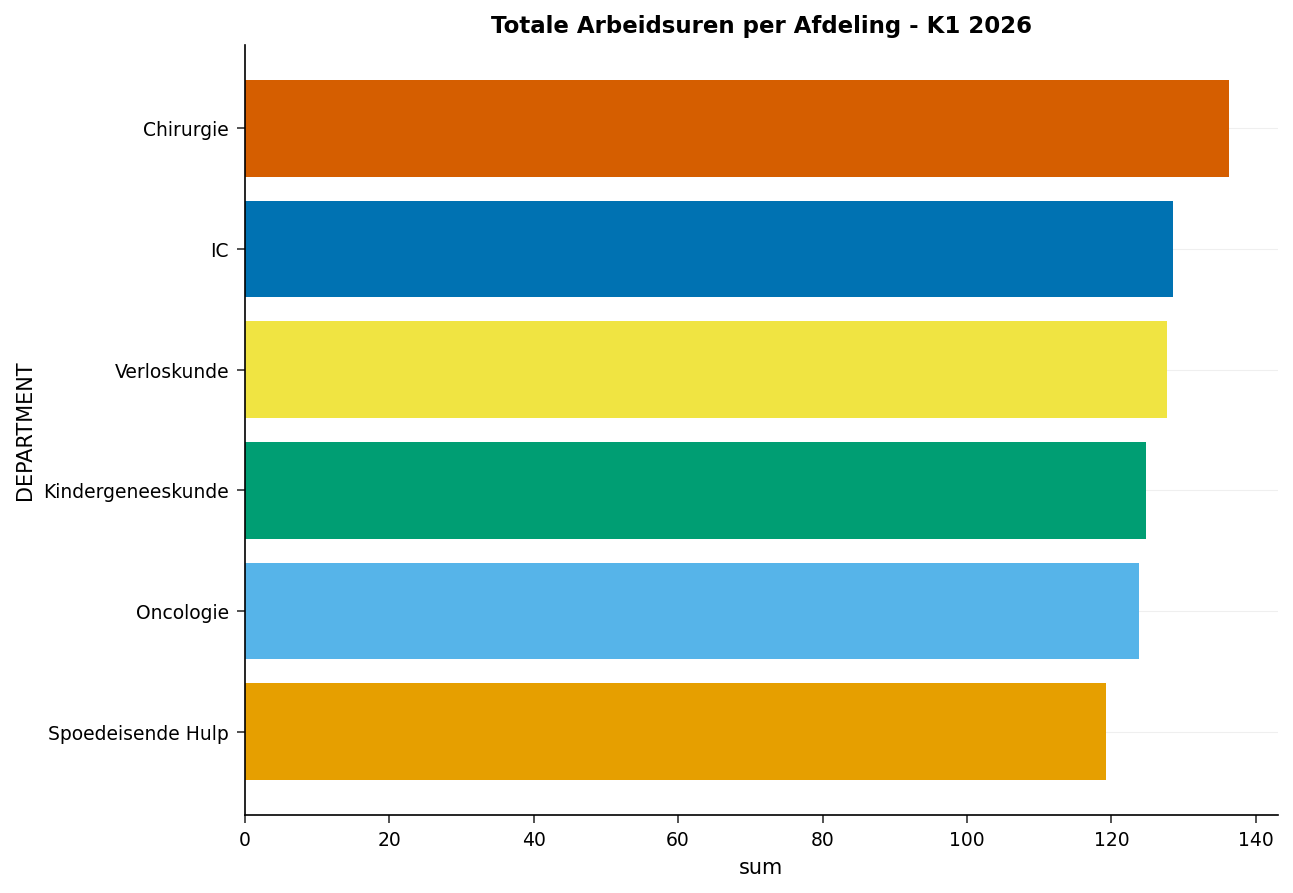

In [4]:
/* --------------------------------------------------------
   Overzicht-HBAR: totale arbeidsuren per afdeling.
   SUMVAR= telt de uren op; DESCENDING rangschikt de staven.
   -------------------------------------------------------- */
PROCEDURE GCHART GEGEVENS=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      AFLOPEND;
    TITEL 'Totale Arbeidsuren per Afdeling - K1 2026';
UITVOEREN;
QUIT;
TITEL;


### Elke afdeling opsplitsen naar personeelscategorie

`GROUP=` tekent een cluster van aangrenzende horizontale staven voor elke afdeling, één staaf per personeelscategorie. Omdat `SUMVAR=hours_worked` van kracht is, meet elke staaf de opgetelde arbeidsuren in plaats van een recordaantal, zodat de grafiek laat zien hoe verplegings-, arts-, paramedische en ondersteuningsuren zich *binnen* elke afdeling verhouden.


In [5]:
/* --------------------------------------------------------
   PATTERN-instructies: samenhangend 4-kleurenpalet,
   één patroon per subgroep personeelscategorie
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Verpleging — diepblauw */
pattern2 VALUE=solid color=cx28A745;   /* Arts — groen     */
pattern3 VALUE=solid color=cxE8650A;   /* Paramedisch — amber */
pattern4 VALUE=solid color=cx6C757D;   /* Ondersteuning — grijs  */


                                   Arbeidsuren per Afdeling naar Personeelscategorie                                    


Bron: Personeelsbeheersysteem | Rapportageperiode: jan-mrt 2026



NOTE: Option TITLE changed to Arbeidsuren per Afdeling naar Personeelscategorie.
NOTE: Option FOOTNOTE changed to Bron: Personeelsbeheersysteem | Rapportageperiode: jan-mrt 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


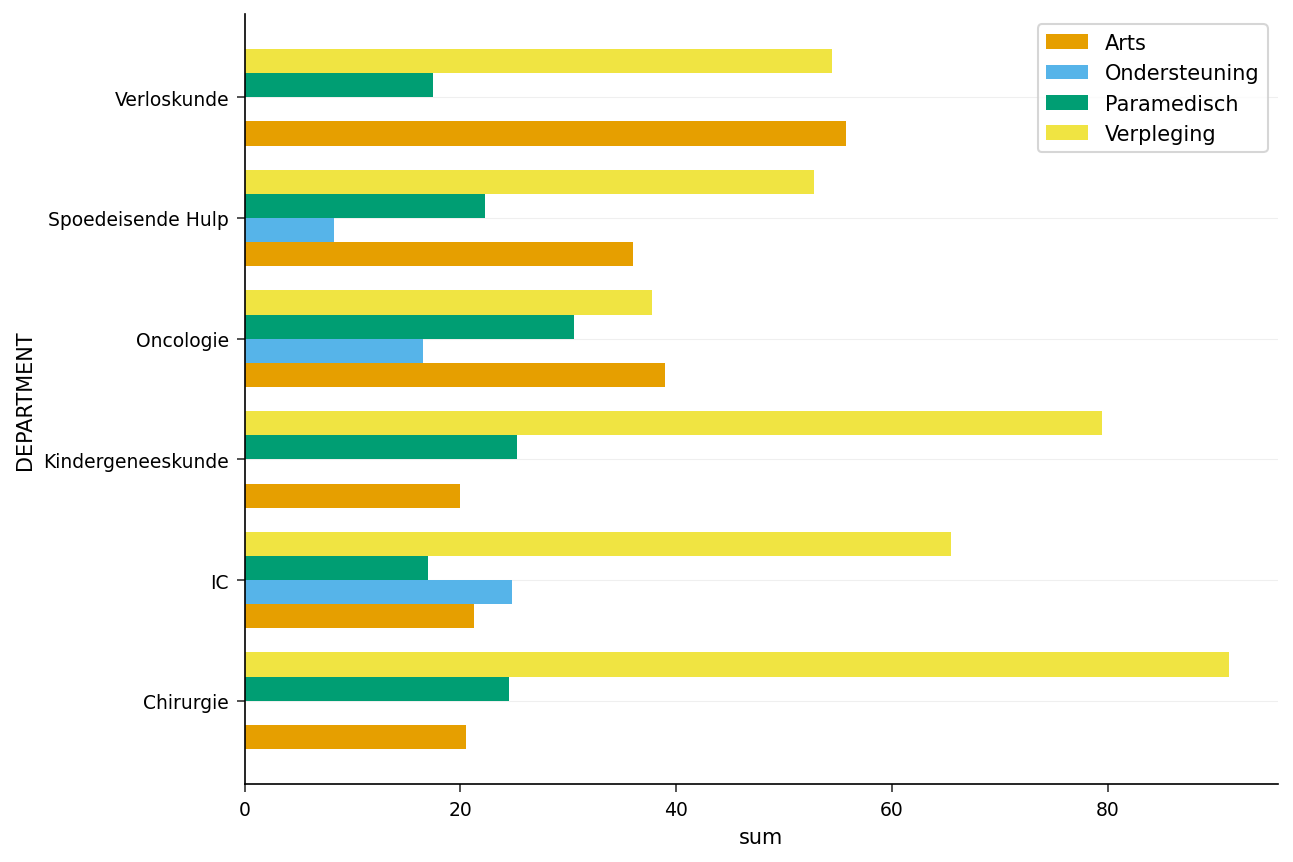

In [6]:
/* --------------------------------------------------------
   HBAR gegroepeerd naar personeelscategorie (GROUP=).
   Elke afdeling wordt een cluster van staven -- één per
   personeelscategorie -- gemeten in opgetelde arbeidsuren.
   -------------------------------------------------------- */
TITEL 'Arbeidsuren per Afdeling naar Personeelscategorie';
footnote JUSTIFY=LEFT
    'Bron: Personeelsbeheersysteem | Rapportageperiode: jan-mrt 2026';

PROCEDURE GCHART GEGEVENS=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
UITVOEREN;
QUIT;

TITEL; footnote;


                                          Arbeidsuren per Afdeling naar Dienst                                          


Gegroepeerde staven splitsen de bijdragen van Dag / Avond / Nacht per afdeling



NOTE: Option TITLE changed to Arbeidsuren per Afdeling naar Dienst.
NOTE: Option FOOTNOTE changed to Gegroepeerde staven splitsen de bijdragen van Dag / Avond / Nacht per afdeling.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


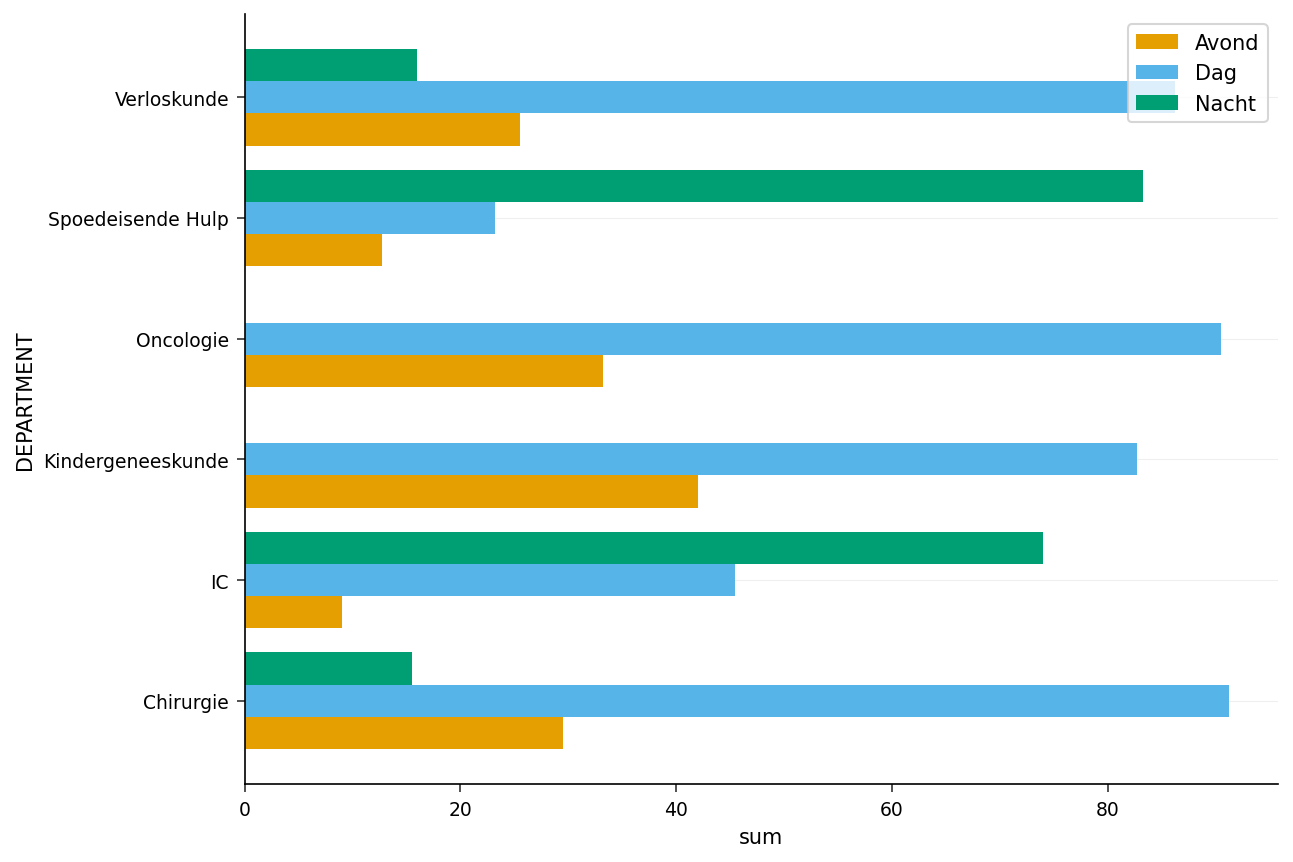

In [7]:
/* --------------------------------------------------------
   HBAR gegroepeerd naar dienst (GROUP=).
   Splitst arbeidsuren van Dag / Avond / Nacht binnen elke
   afdeling -- belicht de 24/7-afdelingen met continue zorgzwaarte.
   -------------------------------------------------------- */
TITEL 'Arbeidsuren per Afdeling naar Dienst';
footnote JUSTIFY=LEFT
    'Gegroepeerde staven splitsen de bijdragen van Dag / Avond / Nacht per afdeling';

PROCEDURE GCHART GEGEVENS=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
UITVOEREN;
QUIT;

TITEL; footnote;



NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


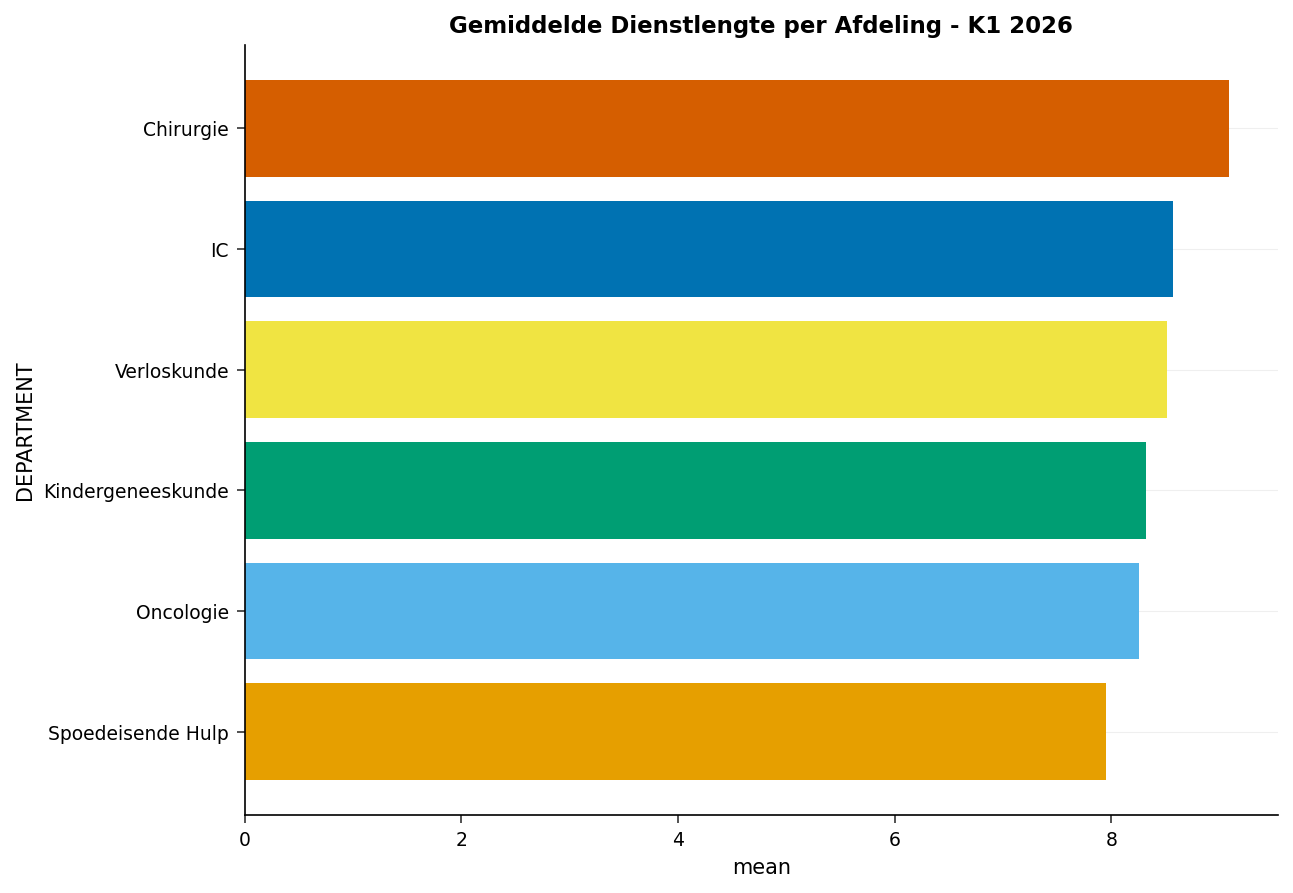

In [8]:
/* --------------------------------------------------------
   Gemiddelde dienstlengte per afdeling (TYPE=MEAN).
   Laat zien of een afdeling lange diensten draait of veel
   kortere, onafhankelijk van het totale volume.
   -------------------------------------------------------- */
PROCEDURE GCHART GEGEVENS=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      AFLOPEND;
    TITEL 'Gemiddelde Dienstlengte per Afdeling - K1 2026';
UITVOEREN;
QUIT;
TITEL;


---

### Interpretatie

Over de 90 dienstrecords lopen de totale arbeidsuren in een smalle bandbreedte van **119,25** (Spoedeisende Hulp) tot **136,25** (Chirurgie), omdat elke afdeling in deze periode dezelfde 15 diensten draait — de rangschikking weerspiegelt dus **dienstlengte**, niet het aantal diensten. Chirurgie staat bovenaan zowel de totaal-uren-grafiek als de gemiddelde-dienst-grafiek met **9,08 uur** per dienst, wat overeenkomt met langere operatieve gevallen en de artsintensieve bezetting die deze gevallen vereisen. Spoedeisende Hulp staat onderaan qua uren (gemiddeld **7,95**) ondanks dat het een van de drukste afdelingen is, omdat het werk daar in kortere diensten met hogere doorloopsnelheid wordt geleverd.

De naar dienst gegroepeerde HBAR en het mozaïekpaneel vertellen het operationeel belangrijke verhaal. **Spoedeisende Hulp en IC zijn nacht-gedomineerd** — respectievelijk 10 van de 15 en 9 van de 15 diensten vallen op Nacht — terwijl **Oncologie en Kindergeneeskunde helemaal geen Nachtdiensten registreren** en zich concentreren op dagdekking (11 en 10 Dagdiensten). Die opsplitsing weerspiegelt de werkelijke ziekenhuisbezetting: afdelingen met continue zorgzwaarte draaien dag en nacht door, terwijl oncologie-infusie en algemene kindergeneeskunde overdag-diensten zijn. Het personeelscategorie-paneel bevestigt een **verplegingsgeleide mix** in elke afdeling, met artsen- en paramedische uren als secundaire lagen.

Voor de K2-personeelsbeoordeling is de nachtdienstconcentratie op Spoedeisende Hulp en IC de post om in de gaten te houden: daar lopen de kosten voor toeslagen en vermoeidheidsbeheer op, en daar heeft elke wijziging in het rooster de grootste budgetimpact.


---

In [9]:
/* --------------------------------------------------------
   Exporteer het afdelingsoverzicht voor het
   personeelsplanningssysteem.
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>